In [ ]:
!pip install faker

In [ ]:
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
fake = Faker()

In [ ]:
genders = ["Male", "Female"]
departments = ["CSE", "IT", "ECE"]
years = ["1st", "2nd", "3rd"]

data = []

for i in range(1, 251):
    student = {
        "Student_ID": i,
        "Name": fake.name(),
        "Gender": random.choice(genders),
        "Department": random.choice(departments),
        "Year": random.choice(years),
        "Maths": random.randint(0, 100),
        "Science": random.randint(0, 100),
        "English": random.randint(0, 100),
        "Attendance": random.randint(50, 100),
        "Internal_Marks": random.randint(0, 25)
    }
    data.append(student)

df = pd.DataFrame(data)

df.tail()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks
245,246,Dylan Wood DDS,Female,IT,3rd,81,86,21,53,10
246,247,Christine Sharp,Male,CSE,2nd,83,72,45,76,0
247,248,Paul Price,Male,CSE,2nd,93,69,30,51,12
248,249,Jennifer Clark,Male,IT,2nd,46,31,93,79,13
249,250,Matthew Lin,Male,CSE,2nd,11,100,97,92,3


In [ ]:
#PREPROCESING
print("Missing Values:\n", df.isnull().sum())

df = df.drop_duplicates()

print("\nDataset Shape:", df.shape)

Missing Values:
 Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal_Marks    0
Total             0
Average           0
Grade             0
dtype: int64

Dataset Shape: (250, 13)


In [ ]:
df["Total"] = df["Maths"] + df["Science"] + df["English"]
df["Average"] = df["Total"] / 3

def grade(avg):
    if avg >= 80:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 40:
        return "C"
    else:
        return "Fail"

df["Grade"] = df["Average"].apply(grade)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total,Average,Grade
0,1,Michael Thompson DVM,Male,CSE,2nd,40,19,44,100,12,103,34.333333,Fail
1,2,Erika Robertson,Male,CSE,3rd,43,40,27,70,0,110,36.666667,Fail
2,3,Juan Moss,Female,IT,2nd,3,68,38,55,4,109,36.333333,Fail
3,4,Bailey Hernandez,Female,IT,3rd,70,69,1,80,13,140,46.666667,C
4,5,Stephanie Grant,Male,CSE,2nd,67,61,97,93,4,225,75.000000,B


In [ ]:
df.describe()

,Student_ID,Maths,Science,English,Attendance,Internal_Marks,Total,Average
count,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,50.620000,49.716000,51.07200,76.140000,12.108000,151.408000,50.469333
std,72.312977,29.364275,28.806712,29.67364,15.008177,7.238919,49.816546,16.605515
min,1.000000,0.000000,0.000000,0.00000,50.000000,0.000000,13.000000,4.333333
25%,63.250000,25.000000,25.000000,28.00000,63.000000,6.000000,112.250000,37.416667
50%,125.500000,52.000000,47.500000,53.50000,77.000000,11.500000,157.000000,52.333333
75%,187.750000,75.000000,76.750000,76.75000,89.000000,18.750000,186.750000,62.250000
max,250.000000,100.000000,100.000000,100.00000,100.000000,25.000000,280.000000,93.333333


In [ ]:
top_students = df.sort_values(by="Average", ascending=False).head(5)
fail_students = df[df["Grade"] == "Fail"]

print("Top 5 Students:\n")
print(top_students)

print("\nFail Students:\n")
print(fail_students)

Top 5 Students:

     Student_ID            Name  Gender Department Year  Maths  Science  \
72           73    Allen Wright    Male        ECE  1st     94       92   
216         217      James Reed    Male        CSE  2nd     86       95   
105         106   Tyler Griffin  Female         IT  2nd     94       70   
103         104  Jeanette House  Female         IT  3rd     89       90   
193         194  Marcus Stevens    Male         IT  1st     87       96   

     English  Attendance  Internal_Marks  Total    Average Grade  
72        94          89               4    280  93.333333     A  
216       99          93               5    280  93.333333     A  
105       88          85              24    252  84.000000     A  
103       73          96              14    252  84.000000     A  
193       65          78              10    248  82.666667     A  

Fail Students:

     Student_ID                  Name  Gender Department Year  Maths  Science  \
0             1  Michael Thompso

In [ ]:
print("Department-wise Average:\n")
print(df.groupby("Department")["Average"].mean())

print("\nGender-wise Average:\n")
print(df.groupby("Gender")["Average"].mean())

print("\nYear-wise Average:\n")
print(df.groupby("Year")["Average"].mean())

Department-wise Average:

Department
CSE    49.707865
ECE    51.348485
IT     50.571930
Name: Average, dtype: float64

Gender-wise Average:

Gender
Female    51.80236
Male      49.36983
Name: Average, dtype: float64

Year-wise Average:

Year
1st    53.712500
2nd    49.849817
3rd    47.898734
Name: Average, dtype: float64


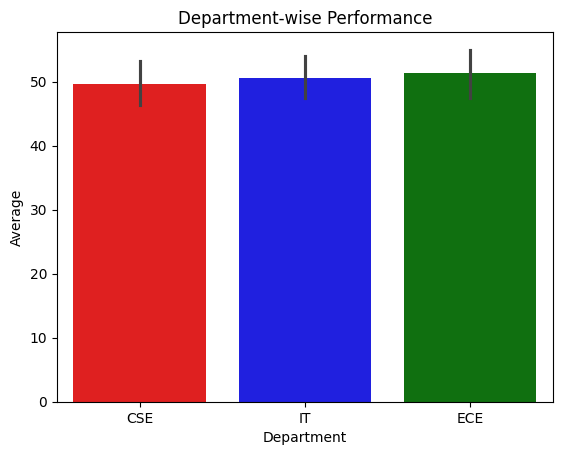

In [ ]:
plt.figure()
sns.barplot(
    x="Department",
    y="Average",
    hue="Department",
    data=df,
    palette=["red", "blue", "green"]
)
plt.title("Department-wise Performance")
plt.show()

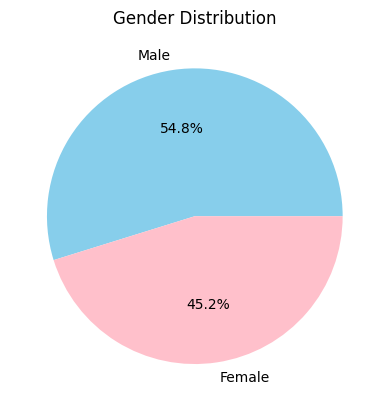

In [ ]:
plt.figure()
df["Gender"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["skyblue", "pink"]
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()


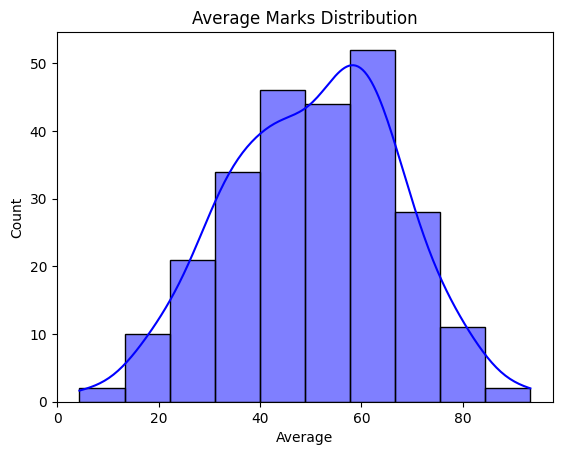

In [ ]:
plt.figure()
sns.histplot(df["Average"], bins=10, kde=True, color="blue")
plt.title("Average Marks Distribution")
plt.show()


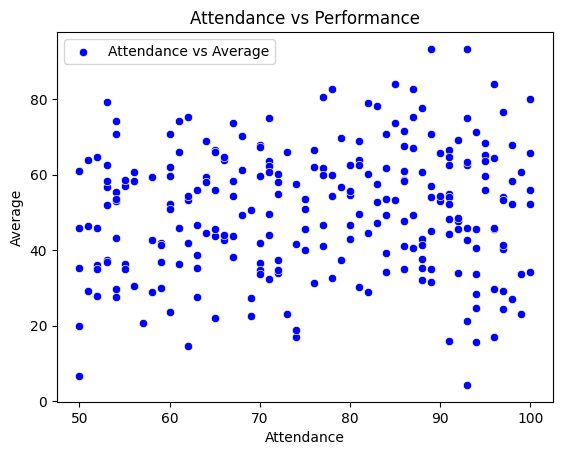

In [ ]:
plt.figure()
sns.scatterplot(
    x="Attendance",
    y="Average",
    data=df,
    color="blue",
    label="Attendance vs Average"
)
plt.title("Attendance vs Performance")
plt.legend()
plt.show()

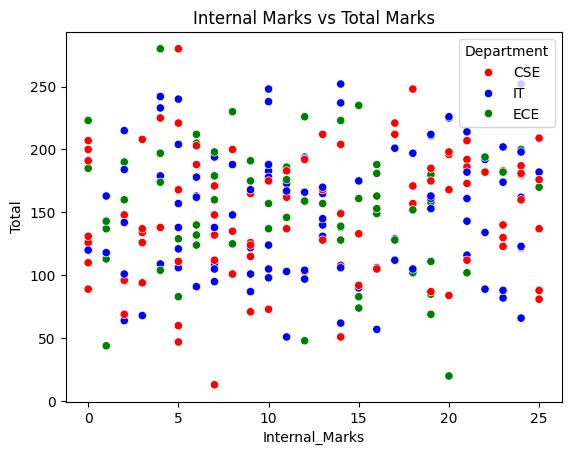

In [ ]:
plt.figure()
sns.scatterplot(
    x="Internal_Marks",
    y="Total",
    hue="Department",
    data=df,
    palette=["red", "blue", "green"]
)
plt.title("Internal Marks vs Total Marks")
plt.show()

In [ ]:
df.to_csv("student_data.csv", index=False)

print("✅ File saved successfully!")

✅ File saved successfully!
